In [1]:
import sys, os

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from src.get_data import load_data
from src.models.poisson_baseline.baseline_main import (
    fit_poisson_glm,
    fit_poisson_xgboost,
)
from src.models.poisson_nn.nn_main import (
    fit_poisson_nn,
    fit_poisson_nn_transfer_learning,
)
from src.models.utils import summarise_model_results
from src.visualisation import (
    compare_models_for_cell,
    compare_r2_across_cells,
    plot_training_curves,
    plot_ytrue_vs_ypred,
)
from src.models.hyperparam_search import grid_search_per_cell
from src.models.poisson_nn.nn_models import PoissonNN
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import PoissonRegressor
from xgboost import XGBRegressor

In [3]:
filenames = ["test1.mat", "test2.mat", "test3.mat", "test4.mat"]
X, Y, cell_ids, rec_ids = load_data("../data/simulated", filenames)

In [4]:
X.shape, Y.shape, cell_ids.shape, rec_ids.shape

((5, 60000), (60000,), (60000,), (60000,))

In [5]:
# baseline models
# Linear Baseline (GLM), Non-linear Baseline (XGBoost)
glm_results = fit_poisson_glm(X, Y, cell_ids)
xgboost_results = fit_poisson_xgboost(X, Y, cell_ids)

In [6]:
summarise_model_results(glm_results, model_name="Poisson GLM")


===== Poisson GLM Summary =====

--- Cell 0.0 ---
Train pseudo-R²:       0.4317
Train log-likelihood:  11064.39
Train deviance:        6.74
Val pseudo-R²:         0.4756
Val log-likelihood:    2305.71
Val deviance:          6.28
Test pseudo-R²:        0.5133
Test log-likelihood:   3262.24
Test deviance:         7.38

--- Cell 1.0 ---
Train pseudo-R²:       0.4302
Train log-likelihood:  11219.63
Train deviance:        6.86
Val pseudo-R²:         0.4729
Val log-likelihood:    2340.27
Val deviance:          6.25
Test pseudo-R²:        0.5080
Test log-likelihood:   3058.10
Test deviance:         7.27

--- Cell 2.0 ---
Train pseudo-R²:       0.4337
Train log-likelihood:  11270.63
Train deviance:        6.58
Val pseudo-R²:         0.4569
Val log-likelihood:    2277.26
Val deviance:          6.48
Test pseudo-R²:        0.5170
Test log-likelihood:   2837.95
Test deviance:         6.74

--- Cell 3.0 ---
Train pseudo-R²:       0.4231
Train log-likelihood:  10968.96
Train deviance:        6.79
V

In [7]:
summarise_model_results(xgboost_results, model_name="Poisson XGBoost")


===== Poisson XGBoost Summary =====

--- Cell 0.0 ---
Train pseudo-R²:       0.8632
Train log-likelihood:  16436.94
Train deviance:        1.62
Val pseudo-R²:         0.8126
Val log-likelihood:    3213.21
Val deviance:          2.24
Test pseudo-R²:        0.7670
Test log-likelihood:   4127.74
Test deviance:         3.53

--- Cell 1.0 ---
Train pseudo-R²:       0.8604
Train log-likelihood:  16661.33
Train deviance:        1.68
Val pseudo-R²:         0.7847
Val log-likelihood:    3172.16
Val deviance:          2.55
Test pseudo-R²:        0.7704
Test log-likelihood:   3930.54
Test deviance:         3.39

--- Cell 2.0 ---
Train pseudo-R²:       0.8617
Train log-likelihood:  16496.34
Train deviance:        1.61
Val pseudo-R²:         0.7887
Val log-likelihood:    3167.74
Val deviance:          2.52
Test pseudo-R²:        0.7674
Test log-likelihood:   3624.52
Test deviance:         3.25

--- Cell 3.0 ---
Train pseudo-R²:       0.8566
Train log-likelihood:  16324.75
Train deviance:        1.

In [8]:
nn_results = fit_poisson_nn(
    X,
    Y,
    cell_ids,
    hidden_sizes=[16],
    lr=1e-3,
    epochs=500,
    scaler=StandardScaler,
    batch_size=None,
)

In [9]:
summarise_model_results(nn_results, model_name="Poisson Neural Network")


===== Poisson Neural Network Summary =====

--- Cell 0.0 ---
Train pseudo-R²:       0.4484
Train log-likelihood:  11272.89
Train deviance:        6.54
Val pseudo-R²:         0.4904
Val log-likelihood:    2345.63
Val deviance:          6.10
Test pseudo-R²:        0.4564
Test log-likelihood:   3068.37
Test deviance:         8.24

--- Cell 1.0 ---
Train pseudo-R²:       0.3994
Train log-likelihood:  10830.26
Train deviance:        7.24
Val pseudo-R²:         0.4408
Val log-likelihood:    2254.59
Val deviance:          6.63
Test pseudo-R²:        0.4299
Test log-likelihood:   2798.73
Test deviance:         8.42

--- Cell 2.0 ---
Train pseudo-R²:       0.3949
Train log-likelihood:  10796.82
Train deviance:        7.04
Val pseudo-R²:         0.4044
Val log-likelihood:    2136.24
Val deviance:          7.10
Test pseudo-R²:        0.4358
Test log-likelihood:   2582.99
Test deviance:         7.88

--- Cell 3.0 ---
Train pseudo-R²:       0.4038
Train log-likelihood:  10730.12
Train deviance:   

In [10]:
nn_results[0].keys()

dict_keys(['model', 'scaler', 'train', 'val', 'test', 'y_pred_train', 'y_pred_val', 'y_pred_test', 'y_train', 'y_val', 'y_test', 'train_idx', 'val_idx', 'test_idx', 'train_losses', 'val_losses'])

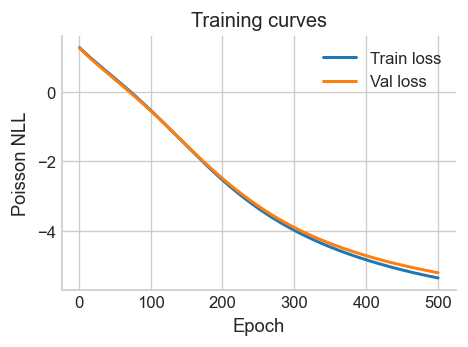

In [11]:
plot_training_curves(
    train_losses=nn_results[0]["train_losses"], val_losses=nn_results[0]["val_losses"]
)

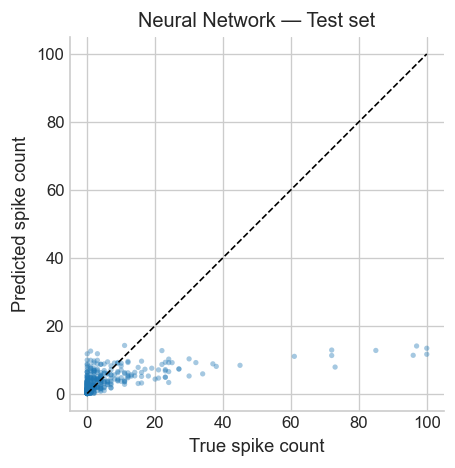

In [12]:
plot_ytrue_vs_ypred(
    y_true=nn_results[0]["y_test"],
    y_pred=nn_results[0]["y_pred_test"],
    title="Neural Network — Test set",
)

In [13]:
nn_tl_results = fit_poisson_nn_transfer_learning(
    X,
    Y,
    cell_ids,
    hidden_sizes=[16],
    lr=1e-3,
    epochs=500,
    scaler=StandardScaler,
    batch_size=None,
)

In [14]:
nn_tl_results[0].keys()

dict_keys(['model', 'cell_head_index', 'y_test', 'y_pred_test', 'test'])

In [15]:
summarise_model_results(
    nn_tl_results, model_name="Poisson Neural Network - Transfer Learning"
)


===== Poisson Neural Network - Transfer Learning Summary =====

--- Cell 0.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.3810
Test log-likelihood:   15288.28
Test deviance:         7.66

--- Cell 1.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.3643
Test log-likelihood:   15013.16
Test deviance:         7.90

--- Cell 2.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.4118
Test log-likelihood:   15664.88
Test deviance:         7.07

--- Cell 3.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.3709
Test log-likelihood:   14933.70
Test deviance:         7.71

--- Cell 4.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.3907
Test log-likelihood:   15287.54
Test deviance:         7.46

--- C

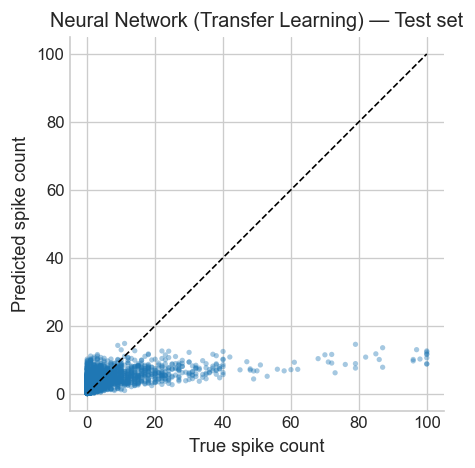

In [16]:
plot_ytrue_vs_ypred(
    y_true=nn_tl_results[0]["y_test"],
    y_pred=nn_tl_results[0]["y_pred_test"],
    title="Neural Network (Transfer Learning) — Test set",
)

In [22]:
cells = sorted(glm_results.keys())

glm_r2 = [glm_results[c]["test"]["pseudo_r2"] for c in cells]
xgb_r2 = [xgboost_results[c]["test"]["pseudo_r2"] for c in cells]
nn_r2 = [nn_results[c]["test"]["pseudo_r2"] for c in cells]
nn_tl_r2 = [nn_tl_results[c]["test"]["pseudo_r2"] for c in cells]

In [23]:
df_test_perf = pd.DataFrame(
    {
        "cell": cells,
        "glm_r2": glm_r2,
        "xgb_r2": xgb_r2,
        "nn_r2": nn_r2,
        "nn_tl_r2": nn_tl_r2,
    }
)

df_test_perf

,cell,glm_r2,xgb_r2,nn_r2,nn_tl_r2
0,0.0,0.513271,0.766979,0.456441,0.380983
1,1.0,0.507967,0.770435,0.429939,0.364255
2,2.0,0.516964,0.767374,0.435794,0.411814
3,3.0,0.499131,0.761546,0.444490,0.370886
4,4.0,0.503410,0.751916,0.504840,0.390689
5,10.0,0.410336,0.695806,0.507353,0.375129
6,11.0,0.428300,0.713880,0.397017,0.323348
7,12.0,0.468016,0.728732,0.349960,0.299860
8,13.0,0.448494,0.720874,0.421895,0.313544
9,14.0,0.425244,0.692670,0.504673,0.339558


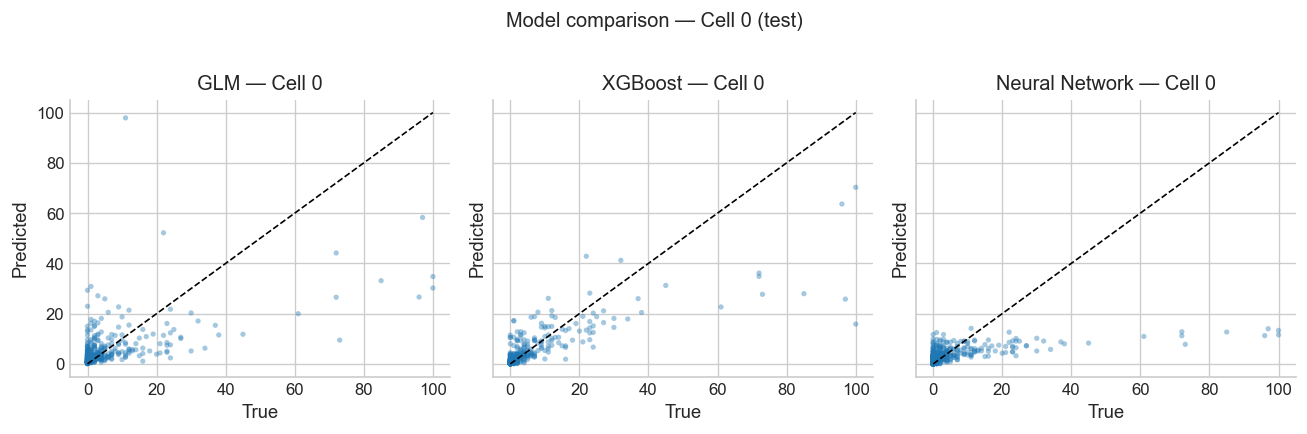

In [19]:
compare_models_for_cell(glm_results, xgboost_results, nn_results, cell=0)

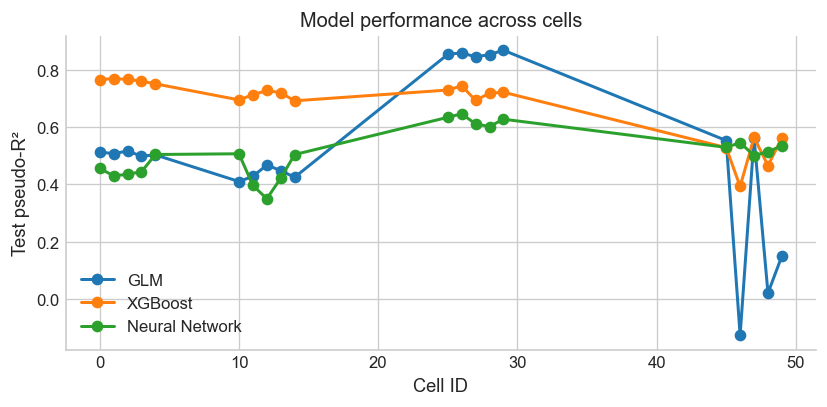

In [20]:
compare_r2_across_cells(glm_results, xgboost_results, nn_results)

In [ ]:
glm_grid = {"alpha": [0.0, 0.1, 1.0, 10.0]}


results_glm_gs = grid_search_per_cell(
    X,
    Y,
    cell_ids,
    model_class=PoissonRegressor,
    param_grid=glm_grid,
    k_folds=3,
)


xgb_grid = {
    "max_depth": [3, 4],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [200, 300],
}

results_xgb_gs = grid_search_per_cell(
    X,
    Y,
    cell_ids,
    model_class=XGBRegressor,
    param_grid=xgb_grid,
    k_folds=3,
)


nn_grid = {
    "hidden_sizes": [(8,), (16,), (32,), (32, 16)],
    "lr": [1e-3, 5e-4],
    "weight_decay": [0.0, 1e-4],
}

# results_nn_gs = grid_search_per_cell(
#     X, Y, cell_ids,
#     model_class=lambda **kw: PoissonNN(n_features=X.shape[0], **kw),
#     param_grid=nn_grid,
#     k_folds=3,
# )

TypeError: PoissonNN.__init__() got an unexpected keyword argument 'lr'